### Шаг 1. Подготовка данных

В данном разделе проводится первичное знакомство с датасетом: анализ структуры данных, типов признаков и наличия пропущенных значений.

#### 1.0 Загрузка библиотек

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
print("Setup complete!")

Setup complete!


#### 1.1 Загрузка данных

Загрузка датасета и вывод первых 5 строк. Это позволяет понять, какие данные содержатся в датасете.

In [3]:
data_2015 = pd.read_csv('../data/2015.csv')
data_2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


#### 1.2 Вывод общей информации о датасете

Ознакомление с информацией о столбцах, размерности и типах данных.

In [5]:
data_2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

Взглянув на описание, можно сделать вывод о наполнении датасета:
- Количество записей = 158
- Количество столбцов = 12
- Типы данных: целое число (1 столбец), строка или иное (2 столбца), дробное число (9 столбцов)

#### 1.3 Вывод основной статистики по датасету

In [6]:
data_2015.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


Просмотр описательной статистики по всему датасету. Статистика отображается по каждому столбцу.  

#### 1.4 Проверка на отсутствие значений 

Перед анализом данных нужно проверить датасет на наличие незаполненных значений, чтобы избежать ошибок. 

In [7]:
data_2015.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

В датасете не было обнаружено отсутствующих значений. Это позволяет анализировать данные без предварительной очистки.  

#### 1.5 Проверка на наличие дубликатов

Иногда одни строки могут дублировать другие, что усложняет работу с анализом данных. Проверка на дубликаты обеспечит корректность дальнейшей работы с данными. 

In [8]:
data_2015.duplicated().sum()

np.int64(0)

Дубликаты не обнаружны, следовательно, не нужно проводить очистку датасета от дублирующихся данных.

#### 1.6 Визуализация распределения переменных

Изображение распределения переменных на гистограммах. Этот шаг показывает распредление значений по интервалам. 

<Axes: xlabel='Happiness Score', ylabel='Count'>

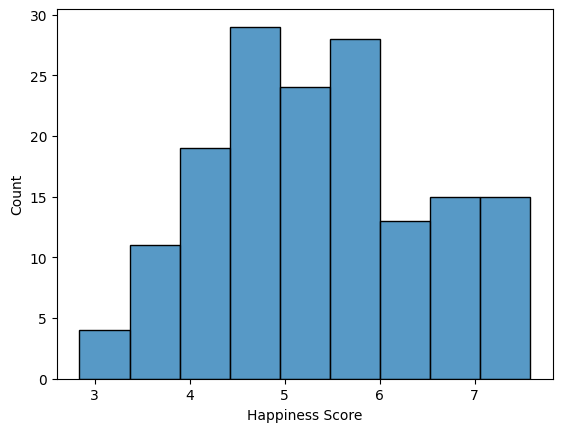

In [6]:
sns.histplot(x=data_2015['Happiness Score'])

В основном люди оценивают свой уровень счастья в интервале 4-6. Это соответствует средним значениям по выборке. 

<Axes: xlabel='Economy (GDP per Capita)', ylabel='Count'>

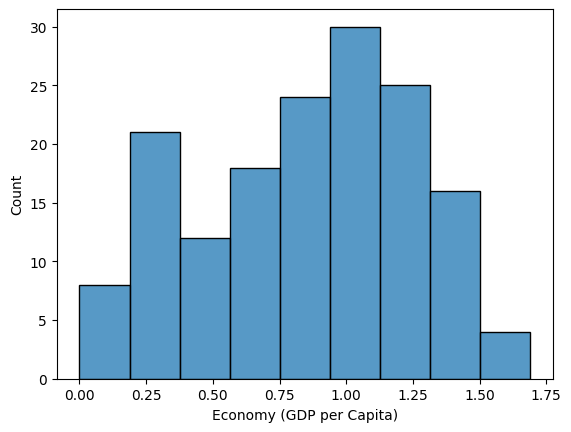

In [7]:
sns.histplot(x=data_2015['Economy (GDP per Capita)'])

ВВП на душу населения у большинства стран в пределах от 0.75 до 1.25 доли. 

#### Вывод 

В ходе подготовки данных было проведено первичное ознакомление с датасетом, а также небольшой первичный анализ в виде гистограмм распределения переменных. Обнаружено, что в датасете нет отсутствующих значений и дубликатов, следовательно, данные готовы к последующей обработке. 